# Configurations

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import sklearn.decomposition
from sklearn.preprocessing import OneHotEncoder 
from sklearn.compose import ColumnTransformer
import seaborn as sns; sns.set()
import math
from typing import List
from types import SimpleNamespace
import scipy

# Temporary
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Data Loading

In [3]:
# The column names in the NSL KDD dataset
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate",
    "srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
    "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label",               # <-- attack label
    "difficulty"           # <-- the missing column!
]

train = pd.read_csv("KDDTrain+.txt", names=col_names)
test  = pd.read_csv("KDDTest+.txt",  names=col_names)

# Selected features
features = [
    # categorical
    "protocol_type", "service", "flag",

    # numeric
    "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "dst_host_srv_count", "dst_host_serror_rate",
    "logged_in", "root_shell", "su_attempted"
]

categorical = ["protocol_type", "service", "flag"]

numeric = [
    "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "dst_host_srv_count", "dst_host_serror_rate",
    "logged_in", "root_shell", "su_attempted"
]

preprocess = ColumnTransformer([ ("cat", OneHotEncoder(handle_unknown="ignore"), categorical), ("num", "passthrough", numeric) ])

# Training and testing set
X_train = train[features]
X_test  = test[features]

# Ensure string values are numerical
X_train = preprocess.fit_transform(X_train).toarray()
X_test  = preprocess.transform(X_test).toarray()

# Label normal traffic as 0 and attack traffic 1
y_train = (train["label"] != "normal").astype(int).values
y_test  = (test["label"] != "normal").astype(int).values

# Shape of data
num_features = X_train.shape[1] # 94 features
N = len(X_train)                # 

# Set validation size to 20%
val_size = int(0.2 * N)

# Validation set
X_val = X_train[:val_size]
y_val = y_train[:val_size]

# Training set
X_train = X_train[val_size:]
y_train = y_train[val_size:]

In [4]:
print(X_test.shape)

(22544, 94)


# Principal Component Analysis

In [10]:
non_exhaustive_len=2000

In [6]:
def plot_embedding(embedding, labels, title=None):
    """ Plot 2D scatter.

    Args:
        embedding (ndarray): data of size (N, 2)
        labels (ndarray):    labels of size (N, )
        title (str):         title of the plot
    """
    assert embedding.shape[1] == 2

    colors = np.where(labels == 1, 'blue', 'green')

    plt.scatter(embedding[:, 0], embedding[:, 1], c=colors, alpha=0.5, s=5 )

    plt.scatter([], [], c='green', label='0')
    plt.scatter([], [], c='blue', label='1')
    plt.legend()

    plt.axis('equal')
    if title:
        plt.title(title)

/home/sappo/.local/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/sappo/.local/lib/python3.11/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


<Axes: title={'center': 'Implementation'}>

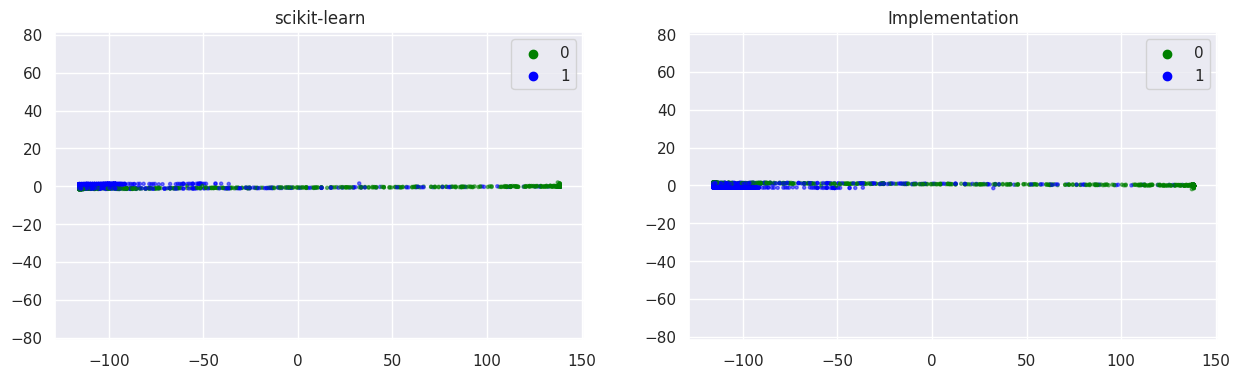

In [12]:
def pca(X, comp):
    """ Project data onto principal components.

    Args:
        X (np.ndarray):   data of size (N, num_features)
        comp (list(int)): specific principal components
    
    Returns:
        (ndarray): projected data
    """
    # Compute data covariance matrix
    X_cen = X - np.mean(X, axis=0)             # Centered data (N, num_features)
    X_cov = (X_cen.T @ X_cen) / X.shape[0]     # Covariance (num_features, num_features)

    # Compute eigenvectors of the matrix
    e_vals, e_vecs = np.linalg.eig(X_cov)       # Eigenvalues (num_features,) and Eigenvectors (num_features,num_features)
    sorted_idxs = np.argsort(e_vals)[::-1]      # Sort indices of largest eignevalues
    e_vecs = e_vecs[:,sorted_idxs]              # Sorted eigenvectors with largest eigenvalues

    # Compute projection of data onto selected eigenvectors
    X_proj = X_cen @ e_vecs[:,comp] # If 2D (N, num_features) x (num_features, 2) -> (N, 2)
    return X_proj

plt.subplots(1, 2, figsize=(15, 4))
pca_embedding = pca(X_train[:non_exhaustive_len,:], [0, 1])
embedding2 = sklearn.decomposition.PCA(n_components=2).fit_transform(X_train[:non_exhaustive_len,:])
plot_embedding(pca_embedding, y_train[:non_exhaustive_len], 'Implementation')
plt.subplot(1, 2, 1)
plot_embedding(embedding2, y_train[:non_exhaustive_len], 'scikit-learn')
plt.subplot(1, 2, 2)

# Multi-dimensional Scaling (MDS)

In [13]:
def compute_edists(X):
    """ Computes all possible pairwise euclidean distances.
    Args:
        X (np.ndarray): Input data with size (N, dim)
    Returns:
        (np.ndarray): Distance matrix with size (N, N)
    """
    return scipy.spatial.distance.cdist(X, X, metric='euclidean')

# Computationally heavy so limited to only 1000 observations
distance_matrix = compute_edists(X_train[:non_exhaustive_len, :])
assert distance_matrix.shape == (non_exhaustive_len, non_exhaustive_len), 'Distance matrix should be square!'

/home/sappo/.local/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/sappo/.local/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/sappo/.local/lib/python3.11/site-packages/sklearn/manifold/_mds.py:794: UserWarning: The provided input is a square matrix. Note that ``fit`` constructs a dissimilarity matrix from data and will treat rows as samples and columns as features. To use a pre-computed dissimilarity matrix, set ``metric='precomputed'``.
  warnings.warn(


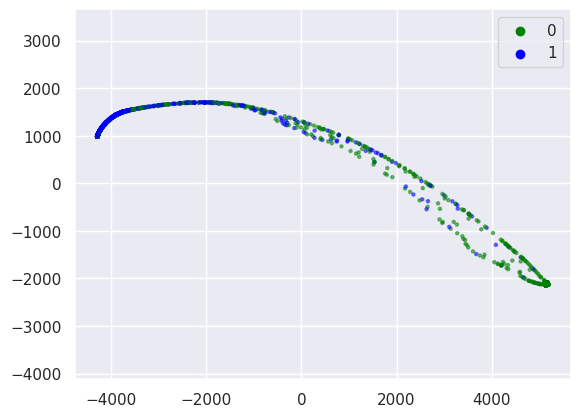

In [14]:
def compute_mds(D, n_components=2):
    """ Compute two-dimensional MDS embedding given a distance matrix.
    Args:
        D (np.ndarray): Distance matrix with size (N, N)
    Returns:
        (np.ndarray): Embedding matrix with size (N, 2)
    """
    mds_object= sklearn.manifold.MDS(n_components=n_components)  # Create two dimensional mds object
    embedding = mds_object.fit_transform(D)                      # Fit distances to mds object to get embedding
    return embedding

# Plot mds embedding
mds_embedding = compute_mds(distance_matrix)
plot_embedding(mds_embedding, y_train[:non_exhaustive_len])

# ISOMAP

478


/home/sappo/.local/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/sappo/.local/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/sappo/.local/lib/python3.11/site-packages/sklearn/manifold/_mds.py:794: UserWarning: The provided input is a square matrix. Note that ``fit`` constructs a dissimilarity matrix from data and will treat rows as samples and columns as features. To use a pre-computed dissimilarity matrix, set ``metric='precomputed'``.
  warnings.warn(


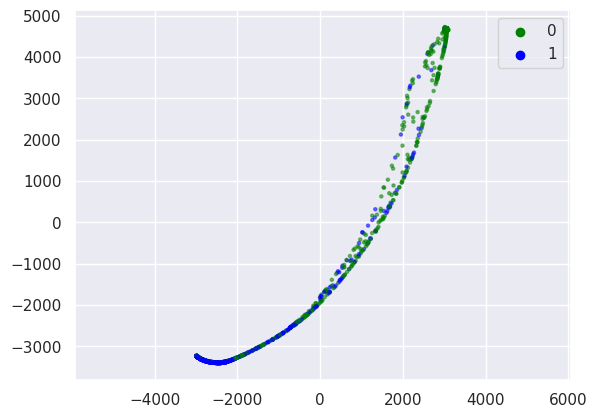

In [16]:
from sklearn.neighbors import NearestNeighbors
from geopy.distance import geodesic
from scipy.sparse.csgraph import shortest_path

def find_connected_graph(X, start=478, max_k=1000):
    """ Find the minimal k neighbors for a KNN connected graph for the geodesic distances
    Args:
        X (np.ndarray): Input data with size (N, dim)
        start (int, optional): Starting with k neighbors. Defaults to 100.
        max_k (int, optional): Lastly testing with k neighbors. Defaults to 1000.
    Returns:
        k, geodesic_distances (int, np.ndarray): the minimal k neighbors and geodesic distance matrix
    """
    
    for k in range(start, max_k + 1):
        # Build KNN graph
        nbrs = NearestNeighbors(n_neighbors=k).fit(X)
        distances, indices = nbrs.kneighbors(X)

        n = X.shape[0]
        G = np.full((n, n), np.inf)

        for i in range(n):
            for j_idx, dist in zip(indices[i], distances[i]):
                G[i, j_idx] = dist
                G[j_idx, i] = dist

        # Compute shortest paths
        geodesic_distances = shortest_path(G, method='D', directed=False)

        # Check connectivity
        if not np.isinf(geodesic_distances).any():
            return k, geodesic_distances

    raise ValueError("Could not find a connected KNN graph")

    
def compute_isomap(X, k=100, geodesic_distances=None):
    """ Apply the isomap algorithm for a two-dimensional embedding
    Args:
        X (np.ndarray): Input data with size (N, dim)
        k (int, optional): k neighbors. Defaults to 100.
        geodesic_distances (np.ndarray, optional): Geodesic distance matrix. Defaults to None.

    Returns:
        _type_: _description_
    """
    if geodesic_distances is not None:
        # Apply MDS to the geodesic distances
        embedding = compute_mds(geodesic_distances)
        return embedding
    else:
        # Compute neighborhood graph G for X e.g. KNN or RN
        nbrs = NearestNeighbors(n_neighbors=k).fit(X)
        distances, indices = nbrs.kneighbors(X)

        # Build adjacency matrix
        n_samples = X.shape[0]
        G = np.full((n_samples, n_samples), np.inf)
        for i in range(n_samples):
            for j_idx, dist in zip(indices[i], distances[i]):
                G[i, j_idx] = dist
                G[j_idx, i] = dist  # make symmetric
        
        # Compute all pair wise geodesic distances of X in G
        geodesic_distances = shortest_path(G, method='D', directed=False)
        
        assert not np.isinf(geodesic_distances).any(), 'Warning: KNN graph is disconnected!'
        
        # Apply MDS to the geodesic distances
        embedding = compute_mds(geodesic_distances)
        return embedding

# Plot isomap embedding
k, geodesic_distances = find_connected_graph(X_train[:non_exhaustive_len], max_k=2000)
print(k)
isomap_embedding = compute_isomap(X_train[:non_exhaustive_len], geodesic_distances=geodesic_distances)
plot_embedding(isomap_embedding, y_train[:non_exhaustive_len])

/home/sappo/.local/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/sappo/.local/lib/python3.11/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


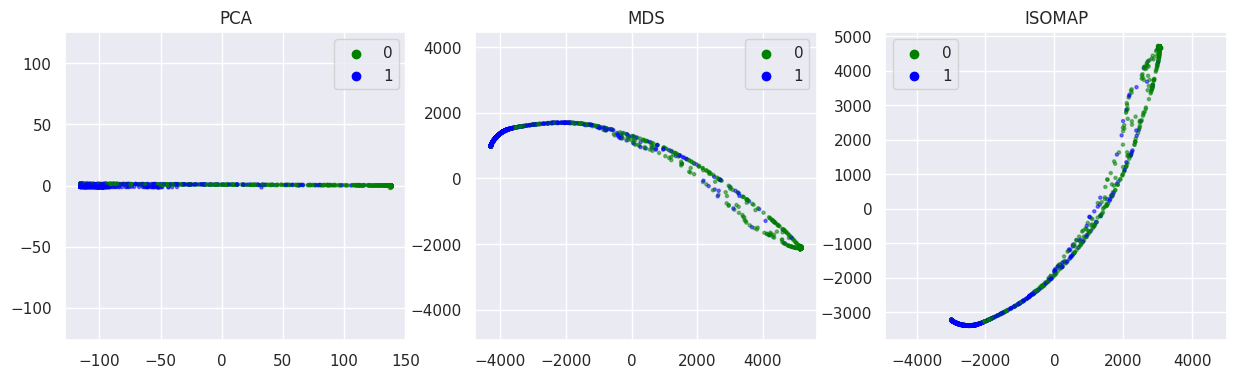

In [17]:
plt.subplots(1, 3, figsize=(15, 4))
plt.subplot(1, 3, 1)
plot_embedding(pca_embedding, y_train[:non_exhaustive_len], 'PCA')
plt.subplot(1, 3, 2)
plot_embedding(mds_embedding, y_train[:non_exhaustive_len], 'MDS')
plt.subplot(1, 3, 3)
plot_embedding(isomap_embedding, y_train[:non_exhaustive_len], 'ISOMAP')